In [1]:
# K-Nearest Neighbors (KNN) - IT22075208

#individual contribution: cancellation prediction using K-Nearest Neighbors (KNN).

#Dataset = hotel_bookings.csv

## Dataset Description
#- Source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
#- Size: 119,390 rows, 32 columns
#- Context: Hotel booking records from a city hotel and resort hotel
#- Target: is_canceled (1 = cancelled, 0 = not cancelled)

#Key columns:
#- lead_time: Days between booking and arrival
#- deposit_type: Type of deposit made
#- previous_cancellations: Past cancellations by the customer
#- adr: Average daily rate of the booking

In [2]:
# Cell 1 - Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score, f1_score
)

In [3]:
# Cell 2 - Load dataset
df = pd.read_csv('hotel_bookings.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Statistical summary
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
# Cell 3 - Quick overview
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data types:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nigh

In [6]:
# Cell 4 - Check missing values (imputation will be done inside the pipeline)
print('Missing values before modeling:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\nTotal missing values:', df.isnull().sum().sum())

Missing values before modeling:
children         4
country        488
agent        16340
company     112593
dtype: int64

Total missing values: 129425


In [7]:
# Cell 5 - Drop leakage and high-missing columns
df = df.drop(['reservation_status', 'reservation_status_date', 'company', 'agent'], axis=1, errors='ignore')

print('Remaining columns:', df.shape[1])

Remaining columns: 28


In [8]:
# Cell 6 - Identify categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').drop('is_canceled', axis=1).columns.tolist()

print('Categorical columns:', len(cat_cols))
print('Numerical columns:', len(num_cols))
print('Sample categorical columns:', cat_cols[:8])

Categorical columns: 10
Numerical columns: 17
Sample categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type']


C:\Users\vidur\AppData\Local\Temp\ipykernel_9900\1037378914.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


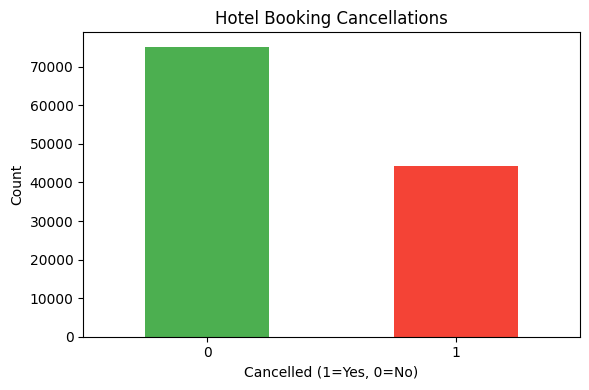

Cancellation rate: 37.04 %


In [9]:
# Cell 7 - Target variable distribution
plt.figure(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'])
plt.title('Hotel Booking Cancellations')
plt.xlabel('Cancelled (1=Yes, 0=No)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Cancellation rate:', round(df['is_canceled'].mean() * 100, 2), '%')

Top features correlated with cancellation:
is_canceled                 1.000000
lead_time                   0.293123
previous_cancellations      0.110133
adults                      0.060017
days_in_waiting_list        0.054186
adr                         0.047557
stays_in_week_nights        0.024765
arrival_date_year           0.016660
arrival_date_week_number    0.008148
children                    0.005048
Name: is_canceled, dtype: float64


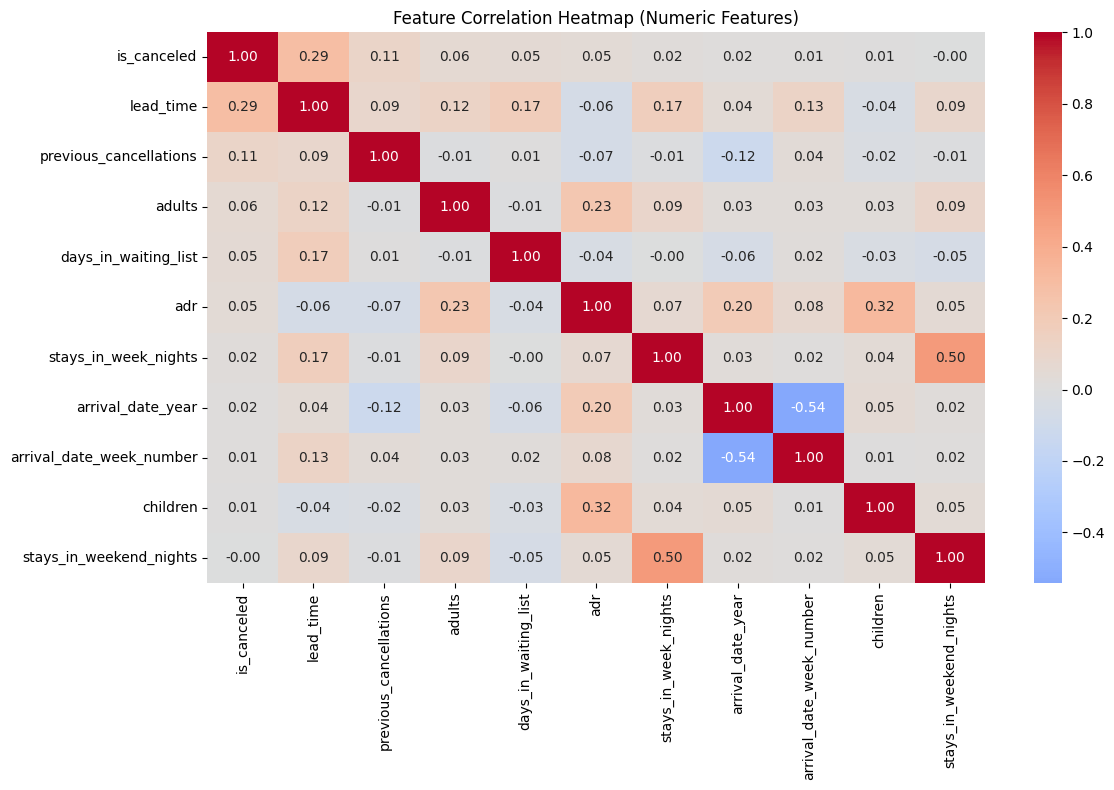

In [10]:
# Cell 8 - Correlation heatmap (top numeric features)
plt.figure(figsize=(12, 8))
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()['is_canceled'].sort_values(ascending=False)

print('Top features correlated with cancellation:')
print(corr.head(10))

sns.heatmap(num_df[corr.head(11).index].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

In [11]:
# Cell 9 - Define features (X) and target (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

print('Features shape:', X.shape)
print('Target distribution:\n', y.value_counts())

Features shape: (119390, 27)
Target distribution:
 is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [12]:
# Cell 10 - Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 95512
Test set size: 23878


In [13]:
# Cell 11 - Build preprocessing pipeline
num_cols2 = X_train.select_dtypes(exclude='object').columns.tolist()
cat_cols2 = X_train.select_dtypes(include='object').columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess2 = ColumnTransformer([
    ('num', num_pipe, num_cols2),
    ('cat', cat_pipe, cat_cols2)
])

print('Preprocessing pipeline ready!')
print('Numerical columns:', len(num_cols2))
print('Categorical columns:', len(cat_cols2))

Preprocessing pipeline ready!
Numerical columns: 17
Categorical columns: 10


C:\Users\vidur\AppData\Local\Temp\ipykernel_9900\399540044.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols2 = X_train.select_dtypes(include='object').columns.tolist()


In [ ]:
# Cell 12 - Faster KNN trained

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Use only a sample from training data for speed
X_train_small = X_train.sample(n=12000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

tuned_pipe = Pipeline([
    ('preprocess', preprocess2),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7],
    'model__weights': ['uniform', 'distance']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=tuned_pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid.fit(X_train_small, y_train_small)
best_knn = grid.best_estimator_

print('Model trained successfully with tuning!')
print('Best params:', grid.best_params_)
print('Best CV Accuracy:', round(grid.best_score_, 4))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Model trained successfully with tuning!
Best params: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Best CV Accuracy: 0.8


In [16]:
# Cell 13 - Predictions and metrics
y_prob = best_knn.predict_proba(X_test)[:, 1]
y_pred = best_knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {accuracy * 100:.2f}%')
print(f'F1 Score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred,
      target_names=['Not Cancelled', 'Cancelled']))

Accuracy:  80.85%
F1 Score:  0.7334
ROC-AUC:   0.8786
PR-AUC:    0.8387

Detailed Report:
               precision    recall  f1-score   support

Not Cancelled       0.84      0.87      0.85     15033
    Cancelled       0.76      0.71      0.73      8845

     accuracy                           0.81     23878
    macro avg       0.80      0.79      0.79     23878
 weighted avg       0.81      0.81      0.81     23878



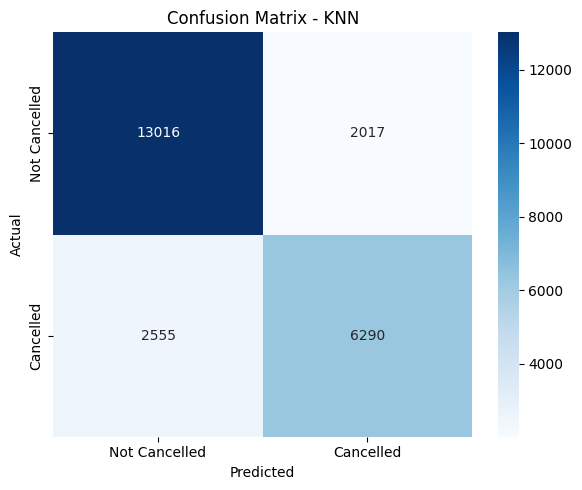

In [17]:
# Cell 14 - Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

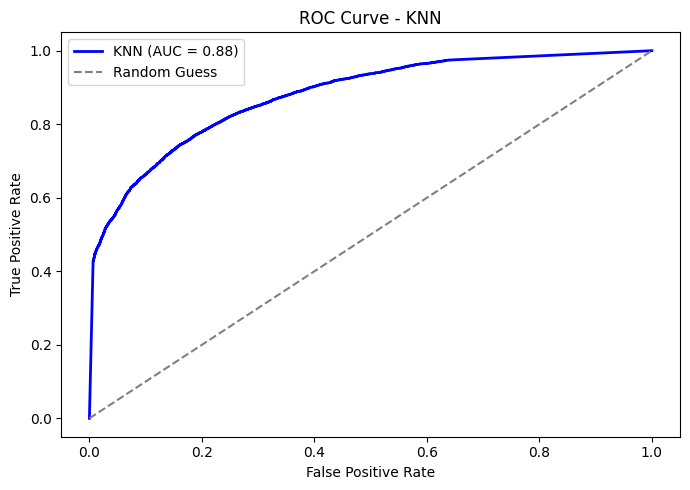

In [18]:
# Cell 15 - ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Cell 17 - Overfitting analysis (train vs test accuracy)
required_vars = ['best_knn', 'X_train', 'X_test', 'y_train', 'y_test']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print('Cannot run overfitting analysis yet.')
    print('Missing variables:', ', '.join(missing_vars))
    print('Run Cells 1 to 16 first, then run this cell.')
else:
    y_train_pred = best_knn.predict(X_train)
    y_test_pred = best_knn.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    accuracy_gap = train_accuracy - test_accuracy

    print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
    print(f'Test Accuracy:     {test_accuracy * 100:.2f}%')
    print(f'Accuracy Gap:      {accuracy_gap * 100:.2f}%')

    if accuracy_gap > 0.05:
        print('Potential overfitting detected (gap > 5%).')
    else:
        print('No strong overfitting signal (gap <= 5%).')

Training Accuracy: 83.05%
Test Accuracy:     80.85%
Accuracy Gap:      2.20%
No strong overfitting signal (gap <= 5%).
